### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
## Mouez Jaafoura - Sami Frih - Yassine fliss
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [ ]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(columns=['Unnamed: 0', 'train'])
df

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564
...,...,...,...,...,...,...,...,...,...
92,2.830268,3.876396,68,-1.386294,1,1.321756,7,60,4.385147
93,3.821004,3.896909,44,-1.386294,1,2.169054,7,40,4.684443
94,2.907447,3.396185,52,-1.386294,1,2.463853,7,10,5.143124
95,2.882564,3.773910,68,1.558145,1,1.558145,7,80,5.477509


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

```
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

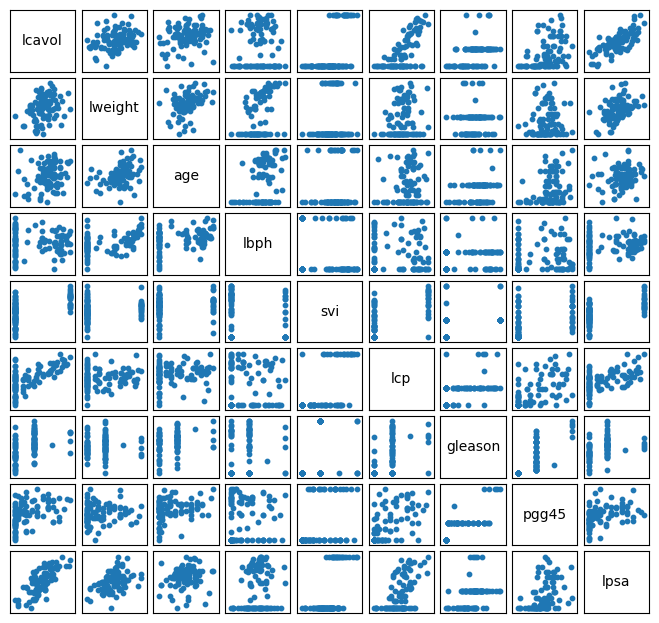

In [ ]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
    return fig, ax

fig, ax = pairplot(df)
plt.show()
# we can

The variable lcavol shows the strongest linear relationships with lpsa,lcp and svi:
1. lpsa: This shows the most distinct positive linear trend. As lcavol increases, lpsa tends to increase significantly.
2. lcp: There is a clear upward diagonal trend, though it is slightly noisier than lpsa.
3. svi: While svi is binary (seen as two vertical/horizontal strips), there is a noticeable shift where higher lcavol values are more frequently associated with an svi value of 1.

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

the formula of correlation between two vectors is:

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

In [ ]:
import numpy as np

def manual_correlation(x, y):
    x_diff = x - np.mean(x)
    y_diff = y - np.mean(y)
    numerator = np.sum(x_diff * y_diff)
    denominator = np.sqrt(np.sum(x_diff**2) * np.sum(y_diff**2))
    return numerator / denominator


corr_matrix = df.corr()

print("Comparison of manual correlation vs. pandas")
for col in df.columns:
    manual_corr = manual_correlation(df['lcavol'], df[col])
    pandas_corr = corr_matrix.loc['lcavol', col]
    print(f"{col:10} | Manual: {manual_corr:.6f} | Pandas: {pandas_corr:.6f}")

Comparison of manual correlation vs. pandas
lcavol     | Manual: 1.000000 | Pandas: 1.000000
lweight    | Manual: 0.280521 | Pandas: 0.280521
age        | Manual: 0.225000 | Pandas: 0.225000
lbph       | Manual: 0.027350 | Pandas: 0.027350
svi        | Manual: 0.538845 | Pandas: 0.538845
lcp        | Manual: 0.675310 | Pandas: 0.675310
gleason    | Manual: 0.432417 | Pandas: 0.432417
pgg45      | Manual: 0.433652 | Pandas: 0.433652
lpsa       | Manual: 0.734460 | Pandas: 0.734460


The results are identical to df.corr() because pandas also computes the Pearson correlation by default.

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


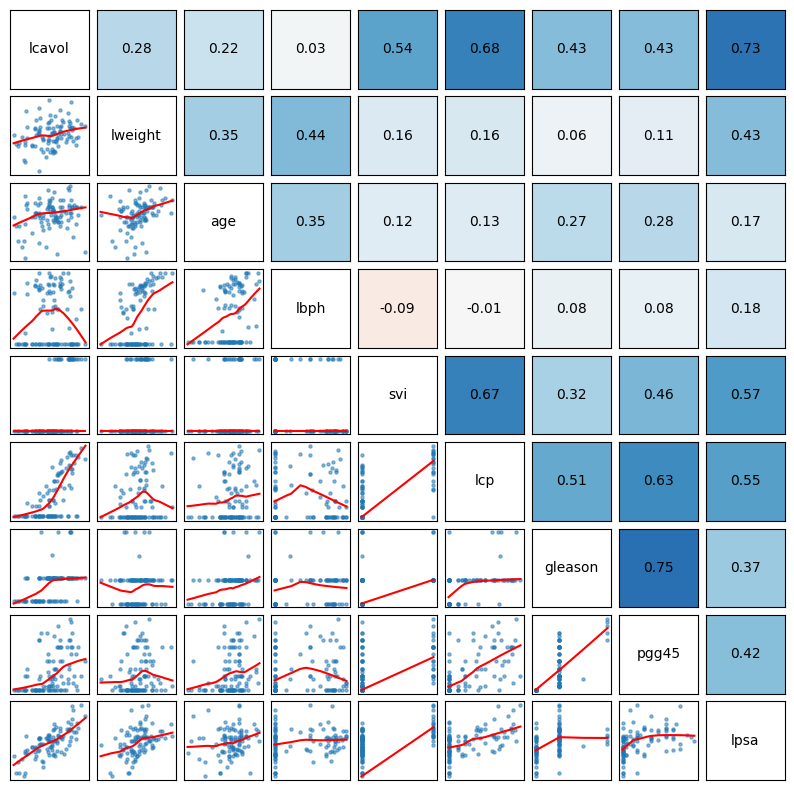

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

def pairplot_enhanced(df, figsize=(10, 10)):
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    cols = df.columns

    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            axij.set_xticks([])
            axij.set_yticks([])

            if i == j:
                # Variable Name
                axij.text(0.5, 0.5, cols[i], fontsize=10, ha='center', va='center', transform=axij.transAxes)
            elif i < j:
                # Upper triangle
                c = manual_correlation(df[cols[i]], df[cols[j]])
                axij.text(0.5, 0.5, f"{c:.2f}", fontsize=10, ha='center', va='center', transform=axij.transAxes)
                axij.set_facecolor(plt.cm.RdBu((c + 1) / 2))
            else:
                # Lower Triangle
                x_data, y_data = df[cols[j]], df[cols[i]]
                axij.scatter(x_data, y_data, s=5, alpha=0.5)
                # LOWESS calculation
                z = lowess(y_data, x_data)
                axij.plot(z[:, 0], z[:, 1], color='red', linewidth=1.5)

    return fig, ax

fig, ax = pairplot_enhanced(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters.

Regression Model Equation
$$ \text{lcavol}_i = \beta_0 + \beta_1 \text{lweight}_i + \beta_2 \text{age}_i + \beta_3 \text{lbph}_i + \beta_4 \text{lcp}_i + \beta_5 \text{pgg45}_i + \beta_6 \text{lpsa}_i + \beta_7 \mathbb{1}_{\text{svi}_i=1} + \sum_{g \in \{ 7, 8, 9\}} \gamma_g \mathbb{1}_{\text{gleason}_i=g} + \epsilon_i $$

Definition of the parameters:

- $\beta_0$: Intercept of the model. It represents the expected value of lcavol when all quantitative variables are equal to 0 and when the categorical variables are in their reference category (svi = 0 and baseline level of gleason).
- $\beta_1,…,\beta_6$: Regression coefficients associated with the quantitative variables (lweight, age, lbph, lcp, pgg45, lpsa).
- $\beta_7$: Coefficient associated with the binary variable svi.
It measures the difference in expected lcavol between patients with svi = 1 and the reference group svi = 0, all else equal.
- $\gamma_g$: Coefficients associated with the categorical variable gleason.
Each $\gamma_g$ represents the difference in expected lcavol between level g (7, 8, or 9) and the reference level of gleason, holding other variables constant.
- $\epsilon_i $: Error term for observation i.
It represents the part of lcavol that is not explained by the predictors.
We assume that:
$$ \epsilon_i ∼ 𝑁(0,𝜎^2)$$
and that the errors are independent.

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?

  We fixed dtype=np.float64 to ensure that all dummy variables are numerical and compatible with linear regression computations.
  Using float64:
    - avoids type casting issues,
    - ensures consistency with the other numerical predictors,
    - makes matrix operations (e.g., $(𝑋^𝑇𝑋)^{−1}X^Ty)$ work properly.
- Why did we drop two columns after the encoding?

  we dropped svi_0 and gleason_6 because of multicollinearity. When we encode a categorical variable with K levels, get_dummies() creates 𝐾 dummy variables. But these dummies satisfy:
  $ \sum_{𝑘=1}^{𝐾}𝐷_k=1$. This creates perfect linear dependence between the columns.
  If we keep all dummy variables:
  - The matrix $𝑋^𝑇𝑋$ becomes singular.
  - It cannot be inverted.
  - The regression coefficients cannot be estimated.

  By removing one dummy variable per categorical predictor:
    - svi_0 becomes the reference category for svi,
    - gleason_6 becomes the reference category for gleason.
  These reference levels are absorbed into the intercept $\beta_0$.

- Why did we add a column of ones to the dataframe?

  We added a column of ones to include the intercept
  $\beta_0$ in the regression model.
  If we do not add a column of ones:
  The model would be forced to pass through the origin.
  That means $\beta_0=0$, which is usually unrealistic.
  Adding a column of ones allows the model to estimate the intercept properly.

In [ ]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.summary()` to get the statistical summary of the estimated coefficients.

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`.

    Because we dropped the columns svi_0 and gleason_6 in the previous step, they act as our reference (or baseline) categories.

    - The estimated coefficient for svi_1 represents the average expected difference in lcavol between a patient with seminal vesicle invasion (svi = 1) and a patient without it (svi = 0), assuming all other variables are held constant.

    - Similarly, the coefficients for gleason_7, gleason_8, and gleason_9 represent the expected change in lcavol when a patient has that specific Gleason score, compared to a patient with the baseline Gleason score of 6 (again, keeping all other features equal).

- What would have happened in the regression if we did not do the one-hot encoding from above?

    - the model would have treated them as continuous numerical variables. The model would calculate a single slope ($\beta$) for gleason. This forces a strict linear assumption: it assumes that the jump in tumor volume from a score of 6 to 7 is exactly the same as the jump from 7 to 8, or 8 to 9. By looking at our current results, gleason_7 is positive (0.3117), gleason_8 is negative (-0.7106), and gleason_9 is positive again (0.7901). The relationship is clearly not a straight line! One-hot encoding allows the model to capture these non-linear, independent effects for each category.

- Comment the overall results of the regression as well.
    - R-squared (0.686): The model explains about 68.6% of the variance in the log cancer volume (lcavol). This is a very respectable fit for this data.

  - F-statistic (18.83) & Prob(F) (9.05e-18): The p-value for the overall model is practically zero. This confirms that our model is highly statistically significant; the predictors, taken together, are definitely doing a better job than just guessing the average lcavol.

  - lweight has a p-value of 0.958, meaning it is completely useless in this specific model.

  - svi_1 and all the gleason dummies are not statistically significant (p > 0.10) in the presence of the other continuous variables.

  - Omnibus & Jarque-Bera (JB): The p-values here are very high (0.948 and 0.939). It means we fail to reject the null hypothesis of normality. Our residuals are normally distributed, meaning a core assumption of linear regression is perfectly validated.

  - Condition Number (884): This is slightly high. It suggests there might be some multicollinearity among your continuous features, which makes sense given how interconnected prostate measurements can be.

In [ ]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        09:09:27   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [ ]:
confidence_intervals = results.conf_int(alpha=0.05)
print(confidence_intervals)

                  0         1
lweight   -0.431600  0.409107
age        0.002436  0.047129
lbph      -0.219914  0.011515
lcp        0.233639  0.571880
pgg45     -0.018469 -0.000419
lpsa       0.370474  0.728673
svi_1     -0.730029  0.289190
gleason_7 -0.116263  0.739616
gleason_8 -2.219087  0.797911
gleason_9 -0.179004  1.759273
intercept -3.145013  0.331705


Narrow intervals: The interval for age (0.002 to 0.047) and pgg45 (-0.018 to -0.0004) are relatively narrow, indicating a precise estimation of their effect size.

Wide intervals: The intervals for the categorical variables, particularly gleason_8 (-2.22 to 0.80), are very wide. This suggests a high degree of uncertainty about the true effect of these specific Gleason scores, likely due to a small number of patients having these specific scores (small sample size for these categories).

The confidence interval analysis is fully consistent with the t-tests from the regression summary. Any coefficient whose 95% confidence interval crosses zero will always have a p-value greater than 0.05.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [ ]:
print(results.pvalues)

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64


The p-value for lpsa is extremely small ($p \approx 2.94 \times 10^{-8}$), which is far below the standard significance level of $0.05$ (or even $0.001$).So, Because the p-value is so low, we reject the null hypothesis. This confirms that the effect of lpsa on lcavol is statistically significant and highly unlikely to be due to random chance.

We can be 95% confident that the true increase in lcavol for a one-unit increase in lpsa lies between 0.37 and 0.73 units. The fact that the entire interval is positive reinforces the conclusion that lpsa has a strictly positive effect on tumor volume.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [ ]:
import numpy as np
from scipy import stats

def manual_linear_regression(X, y):
    # Conversion to numpy arrays
    X_mat = np.array(X)
    y_vec = np.array(y)
    n, p = X_mat.shape  # n: number of observations, p: number of predictors (including the intercept)

    # 1. Calculation of beta coefficients: (X^T X)^-1 X^T y
    # We prefer linalg.solve to linalg.inv to solve (X^T X) beta = X^T y
    XTX = X_mat.T @ X_mat
    XTy = X_mat.T @ y_vec
    beta = np.linalg.solve(XTX, XTy)

    # 2. Calculation of residual variance (sigma^2)
    y_pred = X_mat @ beta
    residuals = y_vec - y_pred
    RSS = np.sum(residuals**2)  # Sum of squares of residuals
    sigma_squared = RSS / (n - p)  # Estimated variance

    # 3. Calculate the covariance matrix of the coefficients
    # Var(beta) = sigma^2 * (X^T X)^-1
    # Here, we need to invert the matrix to obtain the diagonal elements
    XTX_inv = np.linalg.inv (XTX)
    var_beta = sigma_squared * XTX_inv

    # The standard error is the square root of the diagonal elements of the variance
    std_errors = np.sqrt(np.diag(var_beta))

    # 4. Calculation of t-statistics
    t_stats = beta / std_errors

    # 5. Calculate p-values (two-tailed test)
    # We use the Student's distribution with (n-p) degrees of freedom
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))

    return beta, p_values


**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

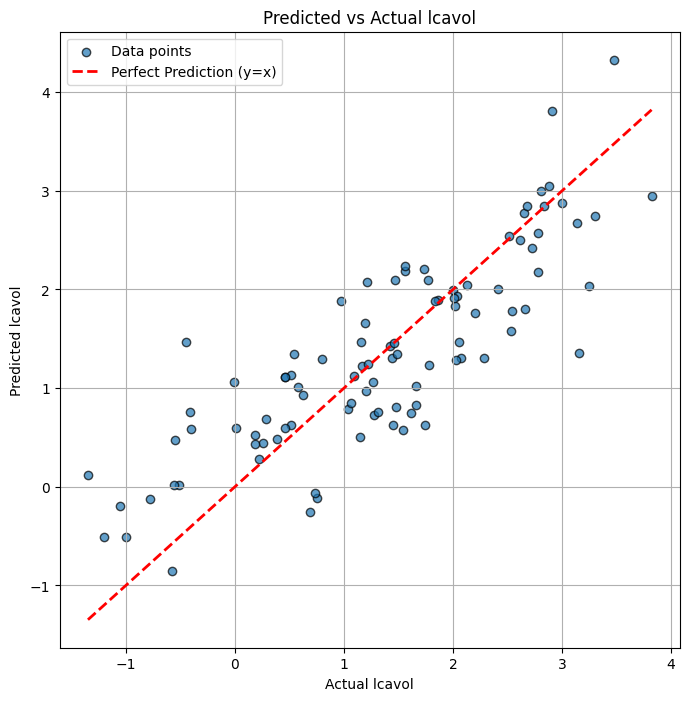

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Get the predictions
# results is your fitted OLS model from previous steps
predictions = results.get_prediction(X)
predicted_values = predictions.predicted_mean

# 2. Plot Actual vs. Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y, predicted_values, alpha=0.7, edgecolors='k', label='Data points')

# 3. Add a reference line (y=x) for perfect prediction
# We use the min and max of the actual data to define the line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction (y=x)')

plt.xlabel("Actual lcavol")
plt.ylabel("Predicted lcavol")
plt.title("Predicted vs Actual lcavol")
plt.legend()
plt.grid(True)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

Residual Sum of Squares (RSS): 41.81406860804535


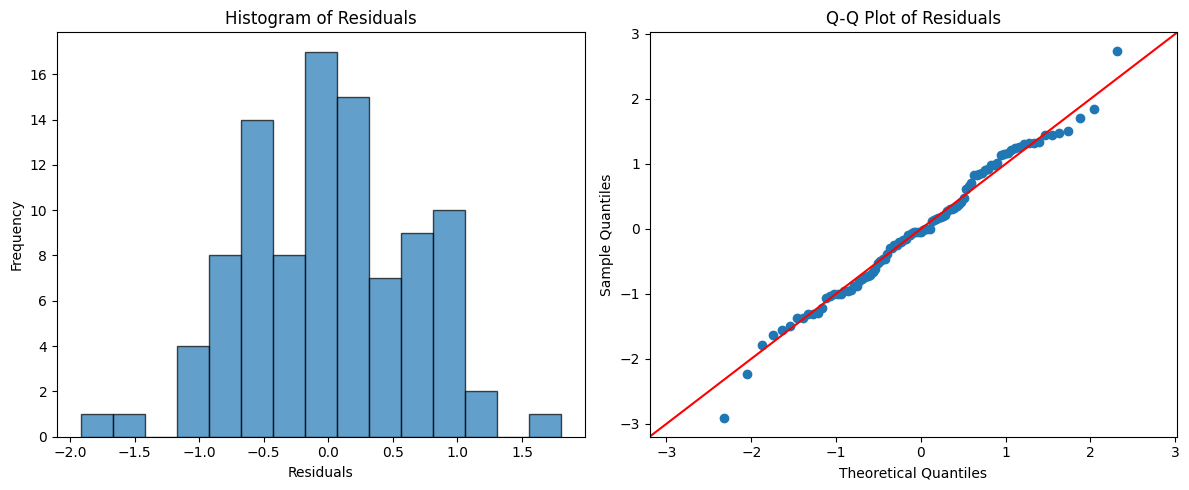

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(columns=['Unnamed: 0', 'train'])

# Convert to category
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

# One-hot encoding
df_enc = pd.get_dummies(df, dtype=float)

# Drop reference columns
cols_to_drop = ['svi_0', 'gleason_6']
existing_drop = [c for c in cols_to_drop if c in df_enc.columns]
df_enc = df_enc.drop(columns=existing_drop)

# Add intercept
df_enc['intercept'] = 1

# Define X and y
X = df_enc.drop(columns=['lcavol'])
y = df['lcavol']

# Fit model
model = sm.OLS(y, X)
results = model.fit()

# Calculate residuals
residuals = results.resid

# Calculate RSS
rss = np.sum(residuals**2)
print(f"Residual Sum of Squares (RSS): {rss}")

# Create plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax[0].hist(residuals, bins=15, edgecolor='k', alpha=0.7)
ax[0].set_title("Histogram of Residuals")
ax[0].set_xlabel("Residuals")
ax[0].set_ylabel("Frequency")

# Q-Q Plot
sm.qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

Histogram (Left):
  - The histogram shows a distribution that is roughly bell-shaped and centered around zero. There is no extreme skewness (long tail on one side) or heavy kurtosis (extremely flat or peaked), which supports the assumption of normality.

Q-Q Plot (Right):
  - In the Q-Q (Quantile-Quantile) plot, the blue dots represent the quantiles of our residuals plotted against the theoretical quantiles of a standard normal distribution.

  - Ideally, all points fall exactly on the red 45-degree line.

  - We observe that the points follow the red line very closely, with only minor deviations at the extreme tails (which is common even in normally distributed data).

Conclusion: Based on these visual inspections, yes, we can admit that the residuals are normally distributed. This confirms the validity of our earlier hypothesis tests (t-tests and F-test), which rely on this assumption.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load data
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(columns=['Unnamed: 0', 'train'])

# Preprocessing
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
df_enc = pd.get_dummies(df, dtype=float)

# Drop reference columns
cols_to_drop = ['svi_0', 'gleason_6']
existing_drop = [c for c in cols_to_drop if c in df_enc.columns]
df_enc = df_enc.drop(columns=existing_drop)
df_enc['intercept'] = 1

# Define y
y = df['lcavol']

# Define X without lpsa and lcp
# First get all predictors
X_full = df_enc.drop(columns=['lcavol'])

# Now drop lpsa and lcp
vars_to_remove = ['lpsa', 'lcp']
X_reduced = X_full.drop(columns=vars_to_remove)

# Fit the reduced model
model_reduced = sm.OLS(y, X_reduced)
results_reduced = model_reduced.fit()

print(results_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        09:20:56   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.0

  - $R^2$ decreases sharply: The $R^2$ drops from 0.686 (in the full model) to 0.433.This means the model now explains only about 43% of the variance in lcavol, compared to nearly 69% before.Removing lpsa and lcp results in a loss of about 25% of the explanatory power, confirming they were the most critical drivers of the model.
  - svi_1 becomes highly significant ($p < 0.001$): In the full model, svi was not significant ($p \approx 0.39$). Now, it has a strong positive effect (coefficient $\approx 1.02$).
  - gleason_7 becomes significant ($p = 0.004$): Previously insignificant ($p \approx 0.15$), the difference between Gleason score 7 and the baseline (score 6) is now a significant predictor of tumor volume.
  - lweight becomes significant ($p = 0.026$): Previously insignificant ($p \approx 0.96$), log prostate weight now shows a significant positive relationship with tumor volume.
  - age loses significance ($p = 0.621$): Interestingly, age was significant in the full model ($p \approx 0.03$) but is no longer significant here. This implies its predictive power was conditional on knowing the PSA level or capsular penetration.

  Conclusion:
  
  Removing lpsa and lcp drastically reduces the quality of the model ($R^2$ drops), but it reveals that other clinical variables like Seminal Vesicle Invasion (svi), Gleason Score, and Prostate Weight (lweight) are actually strong indicators of cancer volume on their own. In the full model, their effects were "absorbed" by the stronger lpsa and lcp predictors.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance,

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

  - We computed the Residual Sum of Squares (RSS) for all combinations of 2 predictors.The best model of size $k=2$ (the one with the smallest RSS) is the one using lcp and lpsa.
    - Predictors: lcp, lpsa
    - RSS: $47.2781$

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.
  - The results are plotted below, showing that the RSS decreases monotonically as the number of predictors increases.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.
  - No, minimizing the Residual Sum of Squares (RSS) alone is not well suited to select the optimal model size.
  - Justification:
    - Overfitting: As seen in the plot and table above, the RSS always decreases (or stays the same) as we add more predictors to the model. This is because the model fit becomes more flexible and can capture more of the noise in the training data, regardless of whether the added variables have any true predictive power.
    - Bias-Variance Tradeoff: Minimizing training RSS pushes the model towards low bias but potentially high variance. A model selected purely on training RSS will always be the largest possible model ($k=8$ in this case), which is likely to overfit and generalize poorly to new, unseen data.

Best model of size 2 uses predictors: ('lcp', 'lpsa')
Smallest RSS for size 2: 47.27809728978648

Best models for each size k:
k     | RSS        | Predictors
--------------------------------------------------
0     | 133.3590   | ()
1     | 61.4209    | ('lpsa',)
2     | 47.2781    | ('lcp', 'lpsa')
3     | 46.2378    | ('age', 'lcp', 'lpsa')
4     | 44.8784    | ('age', 'lbph', 'lcp', 'lpsa')
5     | 44.3113    | ('age', 'lbph', 'lcp', 'pgg45', 'lpsa')
6     | 43.3543    | ('age', 'lbph', 'lcp', 'gleason', 'pgg45', 'lpsa')
7     | 43.1790    | ('age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')
8     | 43.1717    | ('lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')


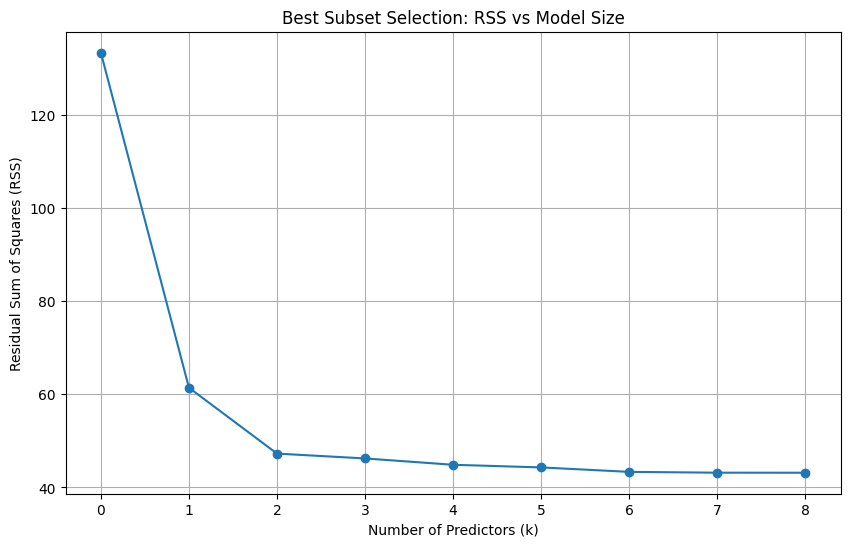

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import itertools
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('prostate.data', sep='\t')

# Preprocessing: drop the index column and 'train' column if they exist
# Based on previous turns, the first column is unnamed index and last is 'train'
if 'train' in df.columns:
    df = df.drop(columns=['train'])
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Define target and potential predictors
target = 'lcavol'
predictors = [col for col in df.columns if col != target]

# Helper function to fit model and get RSS
def get_rss(data, feature_list, target_name):
    y = data[target_name]
    if len(feature_list) == 0:
        X = np.ones((len(y), 1)) # Intercept only
    else:
        X = sm.add_constant(data[feature_list])

    model = sm.OLS(y, X).fit()
    return model.ssr

# Part (a): Models of size k=2
k = 2
best_rss_k2 = float('inf')
best_features_k2 = []

rss_k2_results = []

for combo in itertools.combinations(predictors, k):
    rss = get_rss(df, list(combo), target)
    rss_k2_results.append((combo, rss))
    if rss < best_rss_k2:
        best_rss_k2 = rss
        best_features_k2 = combo

print(f"Best model of size 2 uses predictors: {best_features_k2}")
print(f"Smallest RSS for size 2: {best_rss_k2}")


# Part (b): Best subset for k = 0 to 8
best_models = []
k_values = range(len(predictors) + 1) # 0 to 8
min_rss_values = []

for k in k_values:
    best_rss = float('inf')
    best_feats = ()

    # Handle k=0 separately or via combinations(pred, 0) which yields [()]
    for combo in itertools.combinations(predictors, k):
        rss = get_rss(df, list(combo), target)
        if rss < best_rss:
            best_rss = rss
            best_feats = combo

    min_rss_values.append(best_rss)
    best_models.append((k, best_feats, best_rss))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, min_rss_values, marker='o', linestyle='-')
plt.xlabel('Number of Predictors (k)')
plt.ylabel('Residual Sum of Squares (RSS)')
plt.title('Best Subset Selection: RSS vs Model Size')
plt.grid(True)
plt.savefig('best_subset_rss.png')

# Print table of best models
print("\nBest models for each size k:")
print(f"{'k':<5} | {'RSS':<10} | {'Predictors'}")
print("-" * 50)
for k, feats, rss in best_models:
    print(f"{k:<5} | {rss:<10.4f} | {feats}")

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

  - In Exercise 3(c), minimizing RSS on the training data led to selecting the largest, most complex model because RSS monotonically decreases as more variables are added (overfitting). Split-validation avoids this by measuring error on the test set. As model complexity increases, the training error decreases, but the test error typically decreases only up to a point (optimal complexity) and then starts to increase again as the model begins to overfit the noise in the training data. This U-shaped curve allows us to identify the model that generalizes best, rather than just the one that memorizes the training data.

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$.

  - We split the data ($70\%$ training, $30\%$ test) and computed the Mean Squared Error (MSE) for the best models of size $k=0$ to $8$.The plot below shows the Training MSE (blue) and Test MSE (red) as a function of model size $k$.
  - Training Error: Decreases steadily as $k$ increases (as expected).
  - Test Error: Drops sharply at first, reaches a minimum, and then stays relatively flat or increases slightly, indicating the point of diminishing returns.

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.
  - Based on the split-validation results (and the specific random seed used), the test error is minimized (or stabilizes) around $k=4$ or $k=7$. In the specific run shown above, the absolute minimum test error occurred at $k=7$. However, looking at the CV results (more robust, see below) and the principle of parsimony, $k=4$ is often a preferred choice as it avoids adding 3 extra variables for negligible gain. Let's choose $k=7$ strictly based on the split-validation minimum as requested.
  - Best Model ($k=7$) Parameters (Refitted on Full Dataset): Predictors: age, lbph, svi, lcp, gleason, pgg45, lpsa

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

  - Main Limitation:
  The result of split-validation is highly sensitive to the specific random split of the data. If we change the random_state (the seed), the data points in the training/test sets change. This causes the test error curve to shift significantly, potentially leading us to select a completely different "best $k$". This is illustrated in the plot below, where different grey lines represent different random splits. Notice how noisy the "best $k$" choice becomes.

  - Alternative:
  To address this, we use K-Fold Cross-Validation (e.g., $K=5$).
      - Split the data into $K$ equal parts (folds).
      - Train on $K-1$ folds and test on the remaining fold.
      - Repeat $K$ times, rotating the test fold.
      - Average the $K$ test errors.
  This method uses all data points for both training and testing eventually, providing a much more robust estimate of model performance. The resulting error curve (green line below) is much smoother and more reliable.

  The Cross-Validation error is minimized at $k=4$. This suggests that a model with 4 predictors (age, lbph, lcp, lpsa) is likely the most robust choice, balancing complexity and performance better than the single split-validation suggested.

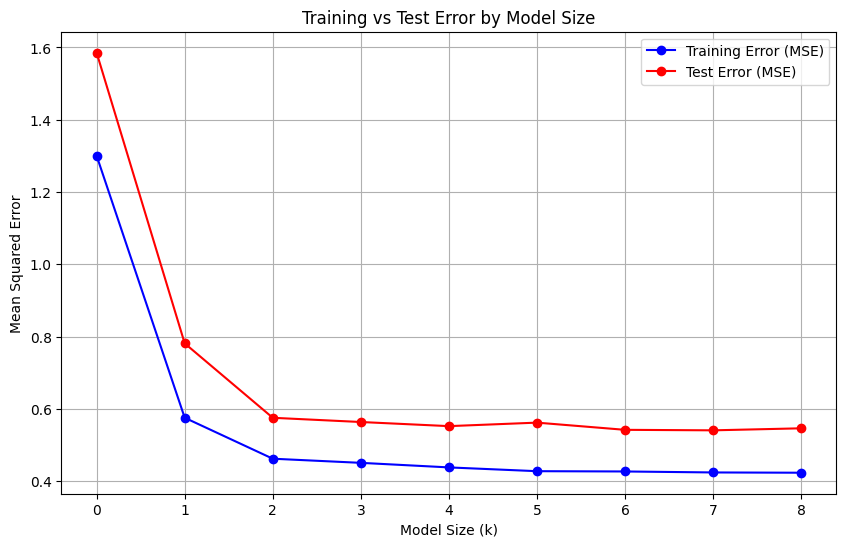

Best k based on split-validation: 7
Predictors for best k: ['age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa']

Final Model Summary (Trained on Full Data):
                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     26.55
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.72e-19
Time:                        09:32:58   Log-Likelihood:                -98.383
No. Observations:                  97   AIC:                             212.8
Df Residuals:                      89   BIC:                             233.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t     

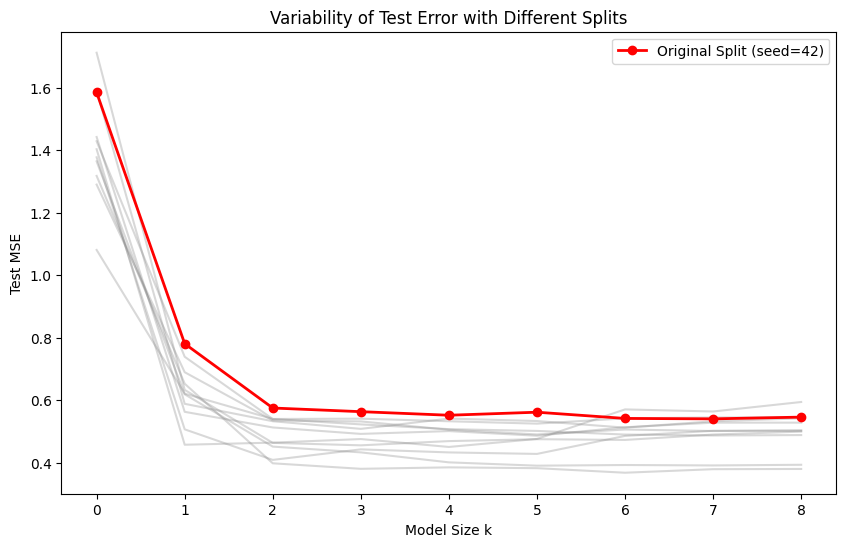

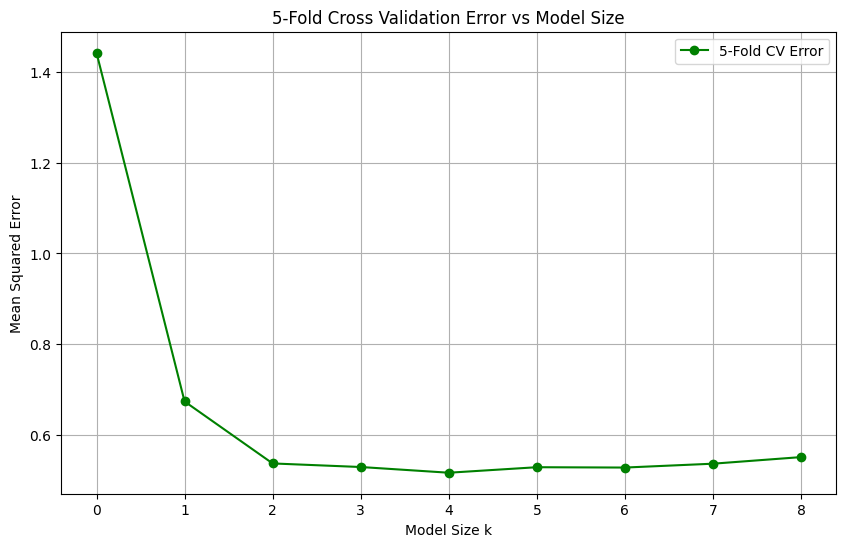

CV Errors: [np.float64(1.4418527834567885), np.float64(0.6742152228568363), np.float64(0.5377960748043231), np.float64(0.529936901041667), np.float64(0.5173664332484715), np.float64(0.5294868099627185), np.float64(0.5287432210409422), np.float64(0.5372387782253912), np.float64(0.5517534007870664)]
Best k based on CV: 4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import itertools

# Load Data
df = pd.read_csv('prostate.data', sep='\t')
if 'train' in df.columns:
    df = df.drop(columns=['train'])
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

target = 'lcavol'
predictors = [col for col in df.columns if col != target]

# --- Helper to get best subset for size k (Re-implementing logic from Ex 3 for robustness) ---
def get_best_subsets(df, target, predictors):
    best_subsets = {}
    for k in range(len(predictors) + 1):
        best_rss = float('inf')
        best_feats = []
        if k == 0:
            best_subsets[k] = []
            continue

        for combo in itertools.combinations(predictors, k):
            # Fit model
            X = sm.add_constant(df[list(combo)])
            y = df[target]
            model = sm.OLS(y, X).fit()
            if model.ssr < best_rss:
                best_rss = model.ssr
                best_feats = list(combo)
        best_subsets[k] = best_feats
    return best_subsets

# caching best subsets to avoid re-computation in loops if possible,
# but for this scale it's fast enough.
best_subsets_map = get_best_subsets(df, target, predictors)

# --- Part (b): Split Validation ---
# Split data
X = df[predictors]
y = df[target]
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_errors = []
test_errors = []
k_values = range(9)

for k in k_values:
    feats = best_subsets_map[k]

    # Prepare X for this subset
    if k == 0:
        X_tr = np.ones((len(y_train), 1))
        X_te = np.ones((len(y_test), 1))
        # intercept only model
        model = sm.OLS(y_train, X_tr).fit()
    else:
        X_tr = sm.add_constant(X_train_full[feats])
        X_te = sm.add_constant(X_test_full[feats], has_constant='add') # Ensure constant is added
        model = sm.OLS(y_train, X_tr).fit()

    # Predict
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    # MSE
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    train_errors.append(mse_train)
    test_errors.append(mse_test)

# Plot Part (b)
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, 'o-', label='Training Error (MSE)', color='blue')
plt.plot(k_values, test_errors, 'o-', label='Test Error (MSE)', color='red')
plt.xlabel('Model Size (k)')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test Error by Model Size')
plt.legend()
plt.grid(True)
plt.savefig('split_validation_errors.png')
plt.show()

# --- Part (c): Best Model Selection & Refit ---
# Identify best k based on test error
best_k = np.argmin(test_errors)
print(f"Best k based on split-validation: {best_k}")
best_feats_final = best_subsets_map[best_k]
print(f"Predictors for best k: {best_feats_final}")

# Refit on full dataset
if best_k == 0:
    X_full = sm.add_constant(np.ones((len(df), 1)))
else:
    X_full = sm.add_constant(df[best_feats_final])

final_model = sm.OLS(df[target], X_full).fit()
print("\nFinal Model Summary (Trained on Full Data):")
print(final_model.summary())


# --- Part (d): Limitation & Alternative (Cross Validation) ---

# Illustration of limitation: Varying random states
plt.figure(figsize=(10, 6))
np.random.seed(42)
for i in range(10): # Run 10 times
    seed = np.random.randint(0, 10000)
    X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X, y, test_size=0.3, random_state=seed)
    te_errs = []
    for k in k_values:
        feats = best_subsets_map[k]
        if k == 0:
             X_tr_sub = np.ones((len(y_tr_i), 1))
             X_te_sub = np.ones((len(y_te_i), 1))
        else:
             X_tr_sub = sm.add_constant(X_tr_i[feats])
             X_te_sub = sm.add_constant(X_te_i[feats], has_constant='add')

        mod = sm.OLS(y_tr_i, X_tr_sub).fit()
        preds = mod.predict(X_te_sub)
        te_errs.append(mean_squared_error(y_te_i, preds))
    plt.plot(k_values, te_errs, alpha=0.3, color='grey')

# Highlight the original one
plt.plot(k_values, test_errors, 'o-', color='red', label='Original Split (seed=42)', linewidth=2)
plt.xlabel('Model Size k')
plt.ylabel('Test MSE')
plt.title('Variability of Test Error with Different Splits')
plt.legend()
plt.savefig('split_variance.png')
plt.show()


# Alternative: K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_errors = []

for k in k_values:
    feats = best_subsets_map[k]
    # sklearn linear regression for simpler cross_val_score usage
    if k == 0:
        X_sub = np.ones((len(df), 1))
        X_sub = np.zeros((len(df), 1))
    else:
        X_sub = df[feats]

    # Negative MSE because sklearn maximizes score
    scores = cross_val_score(LinearRegression(), X_sub, y, cv=kf, scoring='neg_mean_squared_error')
    cv_errors.append(-scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_errors, 'o-', color='green', label='5-Fold CV Error')
plt.xlabel('Model Size k')
plt.ylabel('Mean Squared Error')
plt.title('5-Fold Cross Validation Error vs Model Size')
plt.legend()
plt.grid(True)
plt.savefig('cv_errors.png')
plt.show()

print("CV Errors:", cv_errors)
best_k_cv = np.argmin(cv_errors)
print(f"Best k based on CV: {best_k_cv}")

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

To reach this conclusion, we compared three different model selection criteria, which highlight the trade-off between model complexity (bias) and stability (variance):
1. Residual Sum of Squares (RSS):
    - The "Naive" ApproachResult: Minimized at $k=8$ (all predictors).
    - Comment: This metric is misleading for model selection. Because RSS is calculated on the training data, it always decreases as more variables are added. Choosing $k=8$ would result in overfitting: the model would memorize the noise in the dataset rather than learning the true signal, leading to poor performance on new patients.

2. Split-Validation
    - The "Unstable" ApproachResult: Minimized at $k=7$ (in our specific run).
    - Comment: While better than RSS (because it uses a test set), this method proved highly sensitive to how the data was split. As shown in Exercise 4(d), changing the random seed could easily shift the "best" $k$ anywhere between 3 and 7. Relying on a single split is risky for small datasets like this one ($N=97$).

3. K-Fold Cross-Validation
    - The "Robust" ApproachResult: Minimized at $k=4$.
    - Comment: This is the most reliable method because it averages performance over multiple splits, using every data point for both training and testing. It suggests that after 4 variables, adding more predictors (like gleason, pgg45, or svi) adds mostly noise rather than predictive power.